<a href="https://colab.research.google.com/github/abodassi/California_pricing/blob/main/bike_vs_car_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile
import os

with zipfile.ZipFile('/content/proj.zip', 'r') as zip_ref:
    zip_ref.extractall('proj3')

print(os.listdir('proj3'))


['motorbike', 'car']


In [ ]:
import os

car_folder = os.path.join('proj3', 'car')
motorbike_folder = os.path.join('proj3', 'motorbike')

car_images = [img for img in os.listdir(car_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
num_car_images = len(car_images)

motorbike_images = [img for img in os.listdir(motorbike_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
num_motorbike_images = len(motorbike_images)

print(f"'car': {num_car_images}")
print(f"'motorbike': {num_motorbike_images}")

'car': 866
'motorbike': 1402


In [ ]:

import pandas as pd
import numpy as np
import cv2
import random
import re
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

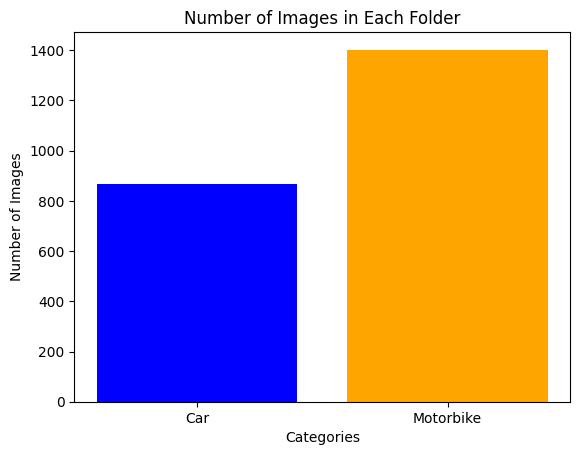

In [ ]:
folders = {'Car': os.path.join('proj3', 'car'), 'Motorbike': os.path.join('proj3', 'motorbike')}

counts = {category: len([img for img in os.listdir(path) if img.endswith(('.png', '.jpg', '.jpeg'))])
          for category, path in folders.items()}

plt.bar(counts.keys(), counts.values(), color=['blue', 'orange'])

plt.title('Number of Images in Each Folder')
plt.xlabel('Categories')
plt.ylabel('Number of Images')

plt.show()

In [ ]:
i=0
labelname = []
images = []
images_path = []
images_pixels = []
labels =[]

In [ ]:
path = "proj3/"
for directory in os.listdir(path):
    labelname.append(directory)
    for img in os.listdir(os.path.join(path,directory)):
        if len(re.findall('.png',img.lower())) != 0 or len(re.findall('.jpg',img.lower())) != 0 or len(re.findall('.jpeg',img.lower())) != 0:
            img_path = os.path.join(os.path.join(path,directory),img)
            images.append(img)
            images_path.append(img_path)
            img_pix = cv2.imread(img_path,1)
            images_pixels.append(cv2.resize(img_pix,(180,180)))
            labels.append(i)
    i= i+1

print("Total Labels: ", len(labels))
print("Total images: ", len(images))
print("Total output: ", len(labelname))
print("Total images_pixels: ", len(images_pixels))

Total Labels:  2268
Total images:  2268
Total output:  2
Total images_pixels:  2268


In [ ]:
shuff = list(zip(images_pixels,labels))
random.shuffle(shuff)
train_data, labels_data = zip(*shuff)

array([[[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [254, 254, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [254, 254, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [254, 254, 254]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [252, 252, 252],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [252, 252, 252],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [253, 253, 253],
        [252, 252, 252],
        [255, 255, 255]]], dtype=uint8)
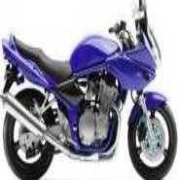

In [ ]:
x_data = np.array(train_data)
x_data[0]

In [ ]:
y_data = np.array(labels_data)
y_data[0:5]

array([0, 0, 0, 0, 1])

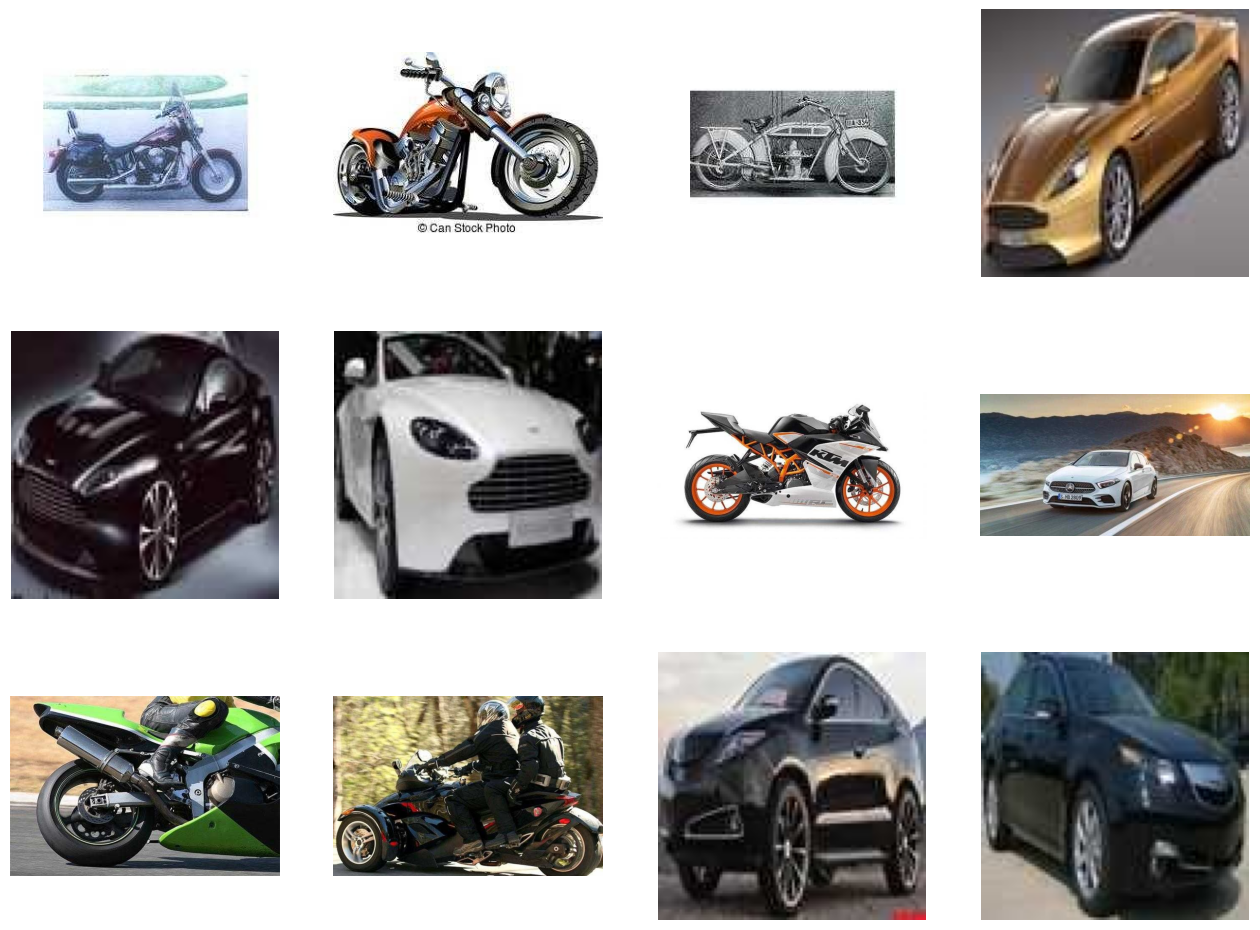

In [ ]:
fig = plt.gcf()
fig.set_size_inches(16,16)

next_pix = images_path
random.shuffle(next_pix)

for i, img_path in enumerate(next_pix[0:12]):

    sp=plt.subplot(4,4,i+1)
    sp.axis('off')

    img = mpimg.imread(img_path)
    plt.imshow(img)
plt.show()

In [ ]:
print("X data shape : ", x_data.shape)
print("Y data shape : ", y_data.shape)

X data shape :  (2268, 180, 180, 3)
Y data shape :  (2268,)


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(x_data,y_data,test_size= 0.2, random_state=20)

print("X train data : ", len(X_train))
print("X label data : ", len(X_val))
print("Y test data : ", len(Y_train))
print("Y label data : ", len(Y_val))

X train data :  1814
X label data :  454
Y test data :  1814
Y label data :  454


In [ ]:
model = Sequential()
model.add(Conv2D(filters = 32, kernel_size = (3,3),padding = 'Same',
                 activation ='relu', input_shape = (180,180,3)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation = "relu"))
model.add(Dense(64, activation = "relu"))
model.add(Dense(1, activation = "sigmoid"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = 'adam', loss= "binary_crossentropy", metrics=["acc"])


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=90,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.3,
    zoom_range=0.3,
    fill_mode='nearest')
datagen.fit(X_train)

In [ ]:
history = model.fit(datagen.flow(X_train,Y_train,batch_size=32),
                             epochs=2, validation_data= (X_val,Y_val), verbose=1)

Epoch 1/2


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


57/57 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - acc: 0.5267 - loss: 162.9380 - val_acc: 0.6322 - val_loss: 0.6418
Epoch 2/2
57/57 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - acc: 0.6311 - loss: 0.6213 - val_acc: 0.6806 - val_loss: 0.5936


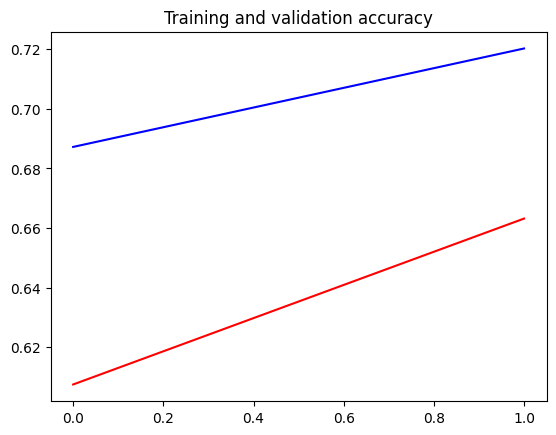

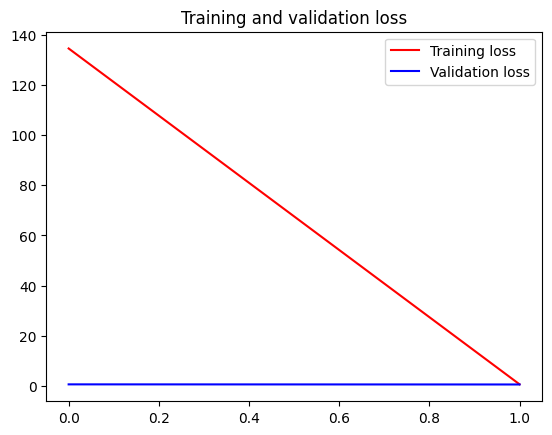

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label="Training accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation accuracy")
plt.title("Training and validation accuracy")

plt.figure()

plt.plot(epochs, loss, 'r', label="Training loss")
plt.plot(epochs, val_loss, 'b', label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
pred = model.predict(X_val)

pred_labels = (pred > 0.5).astype(int)

accuracy = accuracy_score(Y_val, pred_labels)

print(f"Validation Accuracy: {accuracy * 100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 620ms/step
Validation Accuracy: 72.03%


In [ ]:
test_path = "proj3/Car/0BQSIT83SEHW"
img_pix1 = cv2.imread(test_path,1)
resize_img_pix1 = cv2.resize(img_pix, (180,180))
rescale_img = np.array(resize_img_pix1) / 255
iimg = np.expand_dims(rescale_img, axis=0)
prediction = model.predict(iimg)

if prediction[0][0]  > 0.5:
    print("Car")
else:
    print("Motersicle")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Car


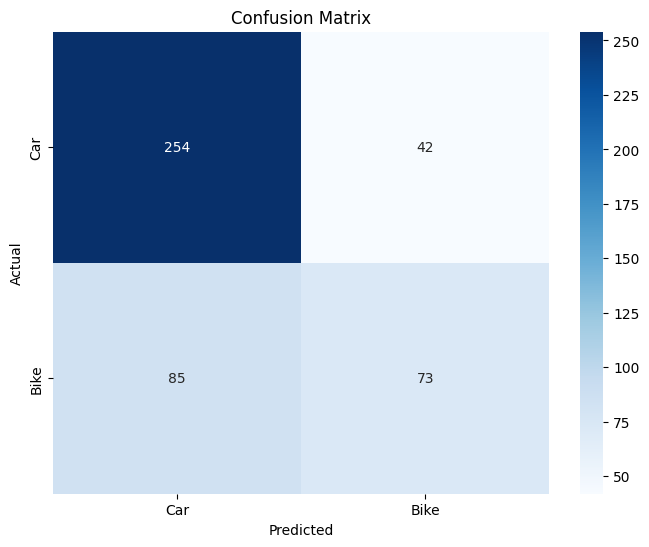

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_val, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Car', 'Bike'],
            yticklabels=['Car', 'Bike'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 180, 180, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 180, 180, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 90, 90, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 90, 90, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 90, 90, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 45, 45, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 45, 45, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 45, 45, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 45, 45, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 22, 22, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 22, 22, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 22, 22, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 22, 22, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 11, 11, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 11, 11, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 11, 11, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 11, 11, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 5, 5, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │       1,638,528 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 16,353,345 (62.38 MB)

 Trainable params: 1,638,657 (6.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=32),
    epochs=4,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/4


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 9/57 ━━━━━━━━━━━━━━━━━━━━ 10:20 13s/step - accuracy: 0.5411 - loss: 6.5212

In [ ]:
pred = model.predict(X_val)
pred_labels = (pred > 0.5).astype(int)
accuracy = accuracy_score(Y_val, pred_labels)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 589ms/step


NameError: name 'accuracy_score' is not defined

In [ ]:
cm = confusion_matrix(Y_val, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


KeyError: 'accuracy'

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.save('vehicle_detection_model.h5')

In [ ]:
model.save('my_model.keras')

In [ ]:
from google.colab import files
files.download('my_model.keras')

In [ ]:
from google.colab import files
files.download('vehicle_detection_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>